**Loading Dataset**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, root_mean_squared_error

df = pd.read_csv('StudentPerformanceFactors.csv')

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


**Cleaning and preprocessing**

In [6]:
df_clean = df.dropna().copy()

df_encoded = pd.get_dummies(df_clean, drop_first=True)

print(f"Dataset shape after cleaning and encoding: {df_encoded.shape}")

Dataset shape after cleaning and encoding: (6378, 28)


**train test split**

In [7]:
X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into training and testing sets.")

Data successfully split into training and testing sets.


**Model Training**

In [10]:
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)

dt_regressor.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


**Evaluation**

In [11]:
y_pred = dt_regressor.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("--- Evaluation Results ---")
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE (Average Point Error): {rmse:.4f}")
print("--------------------------")

--- Evaluation Results ---
R-Squared Score: 0.5155
RMSE (Average Point Error): 2.7439
--------------------------


**Visualizaton**

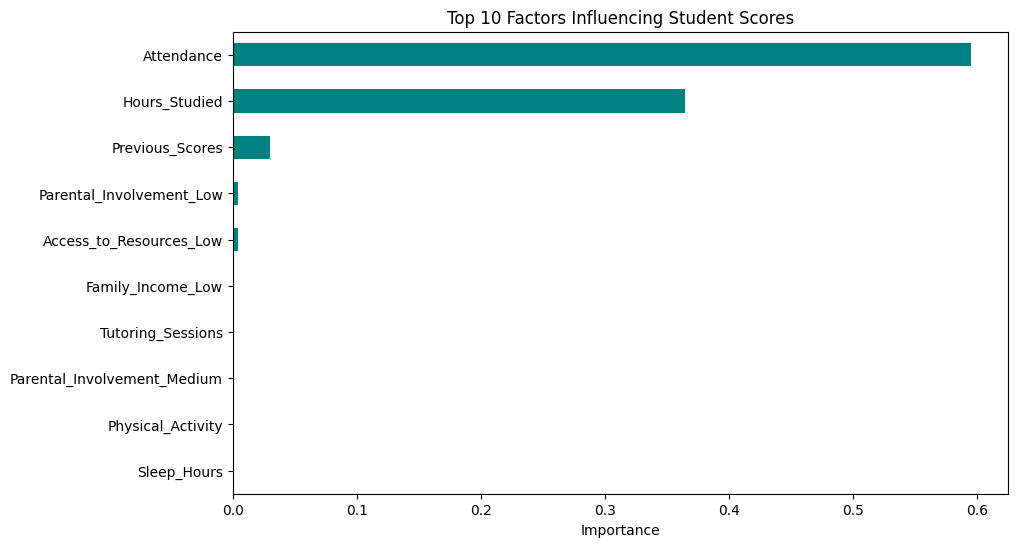

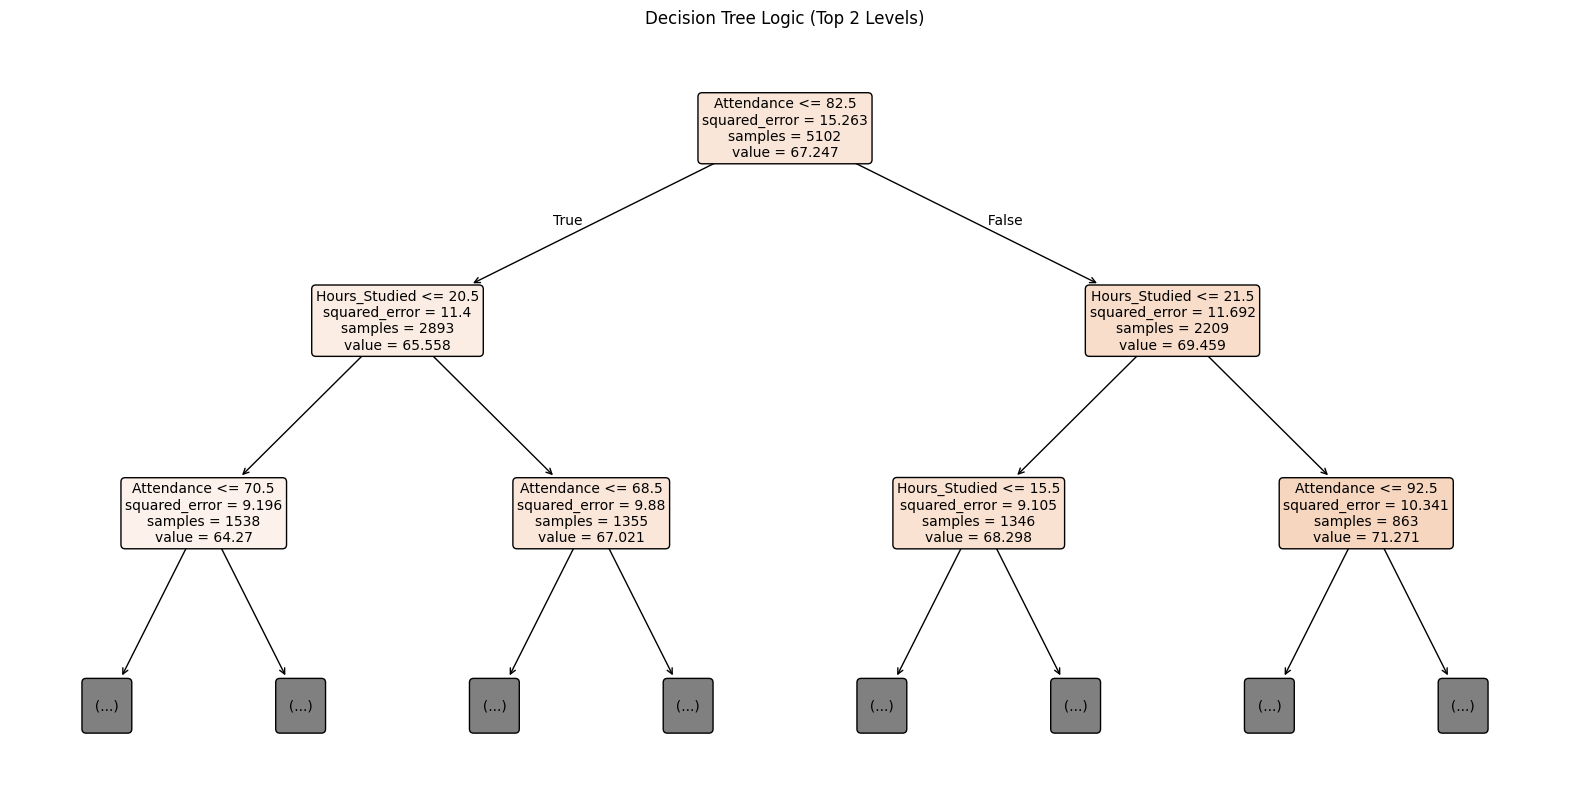

In [12]:
importances = pd.Series(dt_regressor.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Factors Influencing Student Scores')
plt.xlabel('Importance')
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(dt_regressor, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          max_depth=2) 
plt.title('Decision Tree Logic (Top 2 Levels)')
plt.show()